# Import Libraries and Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

In [2]:
df = pd.read_parquet("/home/gq11/Documents/Code/Jupiter Notebook/df_clean.parquet")

In [9]:
# Add some columns
df['mean_estimated_owners'] = df['estimated_owners'].str.split(' - ', expand=True).astype(float).mean(axis=1)
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['price_category'] = np.where(df['price'] > 0, 'Paid', 'Free')

## Highest Estimated Owners

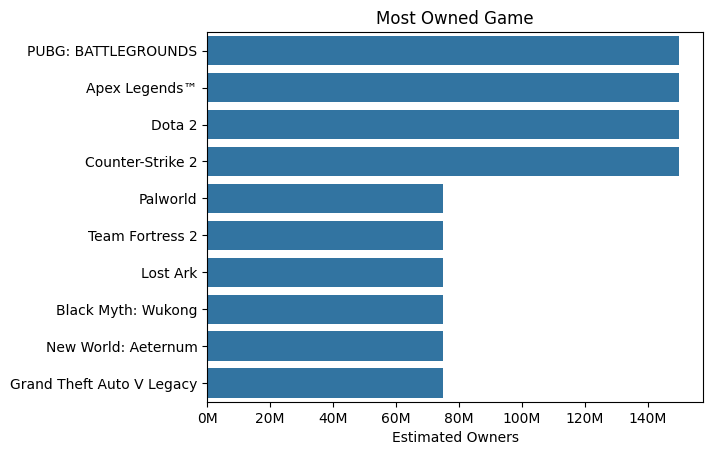

In [ ]:
df2 = df.copy() # i always work on a copy of the df because i too scare to touch the orginial :)

plot = df2[['name', 'mean_estimated_owners']].sort_values(by='mean_estimated_owners', ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(data=plot, x='mean_estimated_owners', y='name')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))
ax.set_xlabel("Estimated Owners")
ax.set_ylabel("")
ax.set_title("Most Owned Game")
plt.show()

"I see many familiar faces here tonight."

The `estimated_owners` column is given as ranges (e.g. Top 4 is both '100M–200M'), and `mean_estimated_owners` is calculated by the midpoint. As a result, a lot of games all end up with the same value.

## Highest Peak Concurrent Users

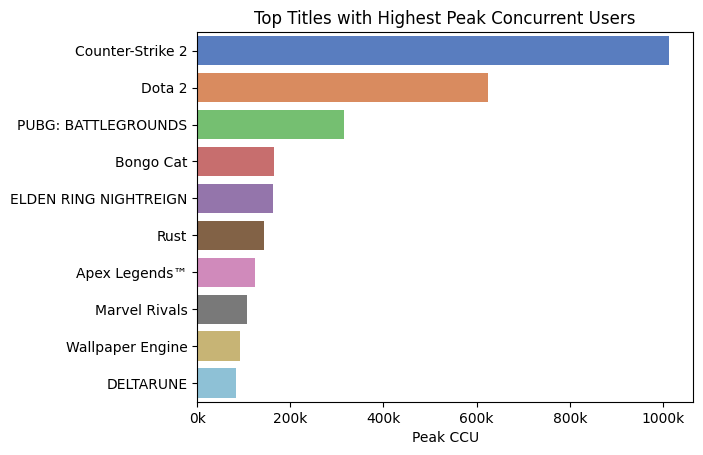

In [ ]:
df2 = df.copy()

plot1 = df2[df2['peak_ccu'] > 0][['name', 'peak_ccu']].sort_values(by='peak_ccu', ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(data=plot1, x='peak_ccu', y='name', hue='name', palette='muted')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-3:.0f}k'))
ax.set_xlabel("Peak CCU")
ax.set_ylabel("")
ax.set_title("Top Titles with Highest Peak Concurrent Users")
plt.show()

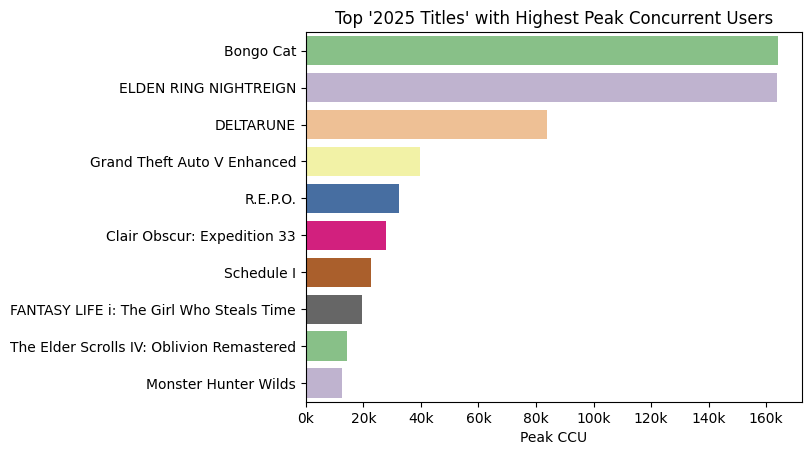

In [4]:
df2 = df.copy()

df2 = df2[(df2['release_year'] == 2025)].sort_values(by='release_month')

plot1 = df2[df2['peak_ccu'] > 0][['name', 'peak_ccu']].sort_values(by='peak_ccu', ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(data=plot1, x='peak_ccu', y='name', hue='name', palette='Accent')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-3:.0f}k'))
ax.set_xlabel("Peak CCU")
ax.set_ylabel("")
ax.set_title("Top '2025 Titles' with Highest Peak Concurrent Users")
plt.show()

Besides **Bongo Cat** (which feels more like a screensaver than a traditional game), I'm impressed by the player counts for **ELDEN RING NIGHTREIGN** and **DELTARUNE**. Meanwhile, the [GOTY 2025 winner](https://youtu.be/WDraAxp-Wp8?si=66dOqj4TueJ6B_bk) **Clair Obscur: Expedition 33** only sits at #6, which maybe makes sense since it's a single-player game.

In [5]:
plot1

,name,peak_ccu
104347,Bongo Cat,164168
17581,ELDEN RING NIGHTREIGN,163599
15313,DELTARUNE,83936
4015,Grand Theft Auto V Enhanced,39502
79168,R.E.P.O.,32349
48641,Clair Obscur: Expedition 33,27880
99453,Schedule I,22757
58017,FANTASY LIFE i: The Girl Who Steals Time,19498
43883,The Elder Scrolls IV: Oblivion Remastered,14420
1423,Monster Hunter Wilds,12494


## Number of Titles Released

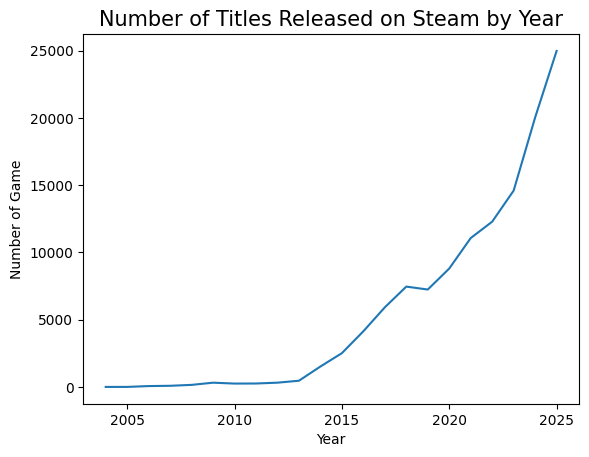

In [ ]:
df2 = df.copy()
df2 = df2[(df2['release_year'] > 2003) & (df2['release_year'] < 2026)].sort_values(by='release_year')

df2.groupby('release_year').size().plot()
plt.xlabel('Year')
plt.ylabel('Number of Game')
plt.title('Number of Titles Released on Steam by Year', fontsize=15)
plt.show()

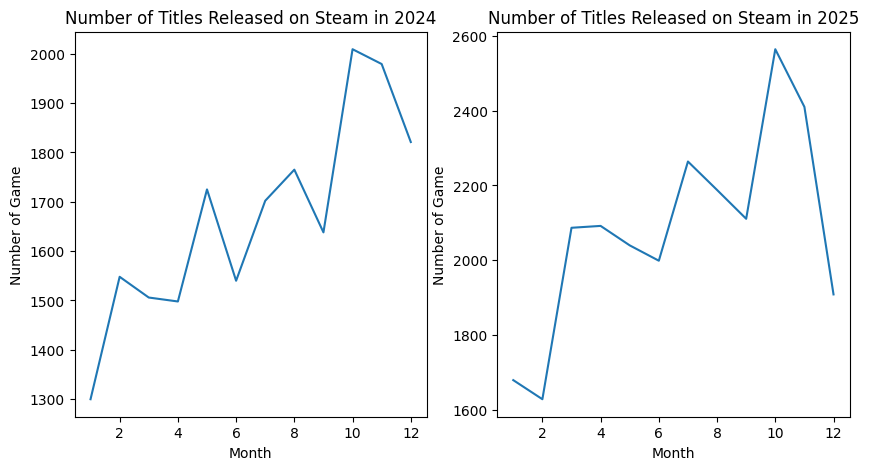

In [21]:
df2 =df.copy()

fig, ax = plt.subplots(1,2, figsize=(10,5))

plot1 = df2[(df2['release_year'] == 2024)].sort_values(by='release_month')
plot1.groupby('release_month').size().plot(ax=ax[0])
ax[0].set_xlabel('Month')
ax[0].set_ylabel('Number of Game')
ax[0].set_title('Number of Titles Released on Steam in 2024')

plot2 = df2[(df2['release_year'] == 2025)].sort_values(by='release_month')
plot2.groupby('release_month').size().plot(ax=ax[1])
ax[1].set_xlabel('Month')
ax[1].set_ylabel('Number of Game')
ax[1].set_title('Number of Titles Released on Steam in 2025')

plt.show()



The release date patterns for 2024 and 2025 are pretty similar. more and more games drop toward the end of the year, with peak in around October-November, releasing games in the autumn has become a trend among developers.

## Genres Analysis

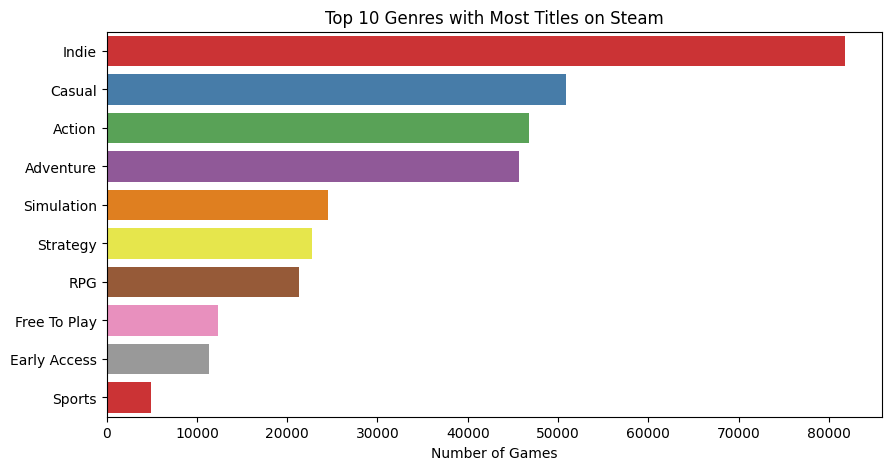

In [72]:
df2 = df.copy()
df2 = df2[['appID', 'mean_estimated_owners', 'genres']].explode('genres')

plot1 = df2['genres'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(x=plot1.values, y=plot1.index, hue=plot1.index, palette="Set1")
ax.set_xlabel('Number of Games')
ax.set_ylabel('')
ax.set_title('Top 10 Genres with Most Titles on Steam')
plt.show()

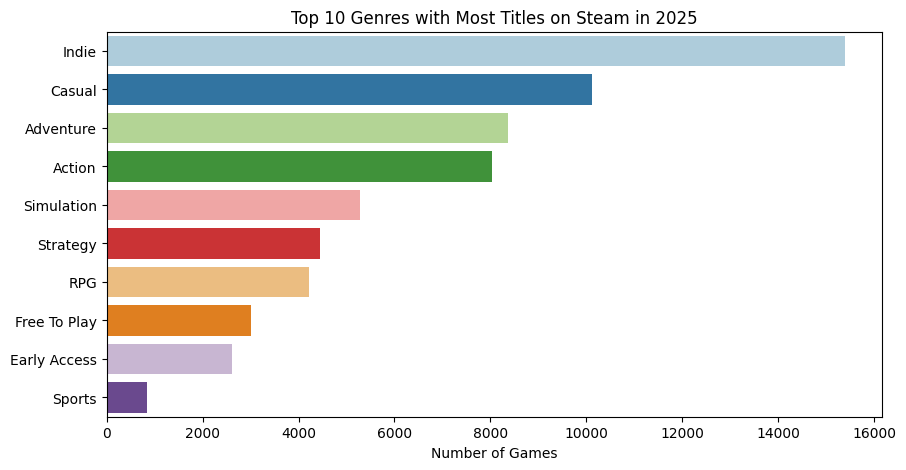

In [82]:
df2 = df.copy()

df2 = df2[(df2['release_year'] == 2025)].sort_values(by='release_month')
df2 = df2[['mean_estimated_owners', 'genres']].explode('genres')

plot1 = df2['genres'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(x=plot1.values, y=plot1.index, hue=plot1.index, palette="Paired")
ax.set_xlabel('Number of Games')
ax.set_ylabel('')
ax.set_title('Top 10 Genres with Most Titles on Steam in 2025')
plt.show()

The chart looks exacly the same as above.

[]

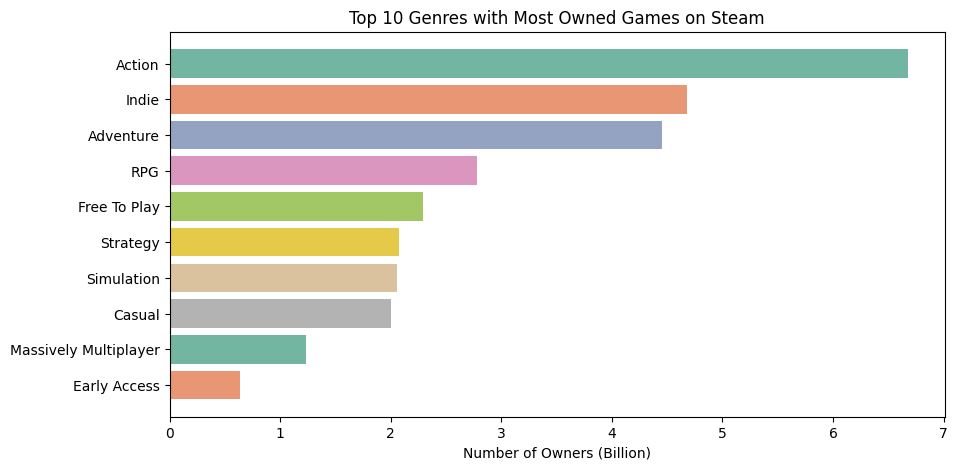

In [24]:
df2 = df.copy()

df2 = df2[['mean_estimated_owners', 'genres']].explode('genres')
plot2 = df2.groupby('genres')['mean_estimated_owners'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(x=plot2.values, y=plot2.index, hue=plot2.index, palette="Set2")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-9:.0f}'))
ax.set_xlabel('Number of Owners (Billion)')
ax.set_ylabel('')
ax.set_title('Top 10 Genres with Most Owned Games on Steam')
plt.plot()

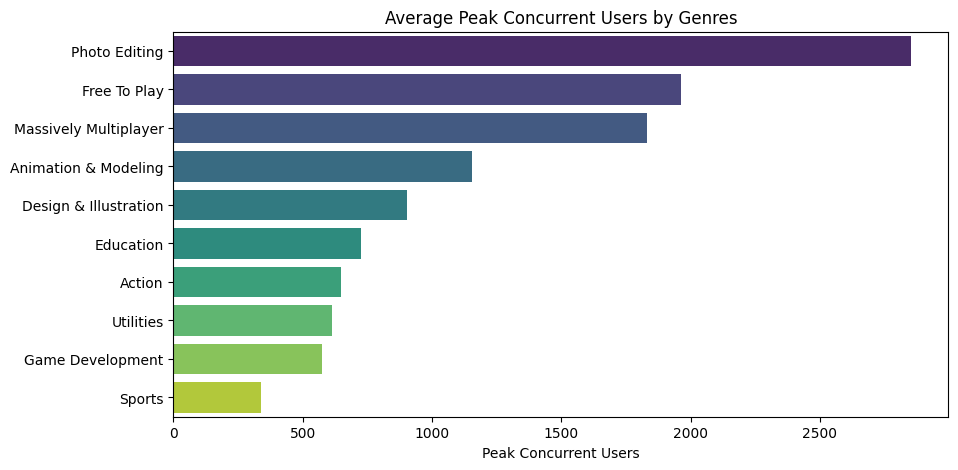

In [57]:
df2 = df.copy()
df2 = df2[['peak_ccu', 'genres']].explode('genres')

plot2 = df2[df2['peak_ccu'] > 0].groupby('genres')['peak_ccu'].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(x=plot2.values, y=plot2.index, hue=plot2.index, palette="viridis")
ax.set_xlabel('Peak Concurrent Users')
ax.set_ylabel('')
ax.set_title('Average Peak Concurrent Users by Genres')
plt.show()

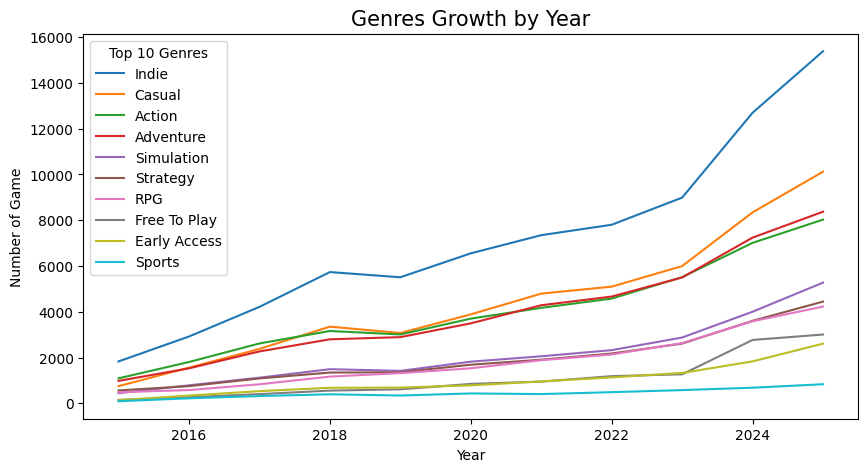

In [11]:
df2 = df.copy()
df2 = df2[(df2['release_year'] > 2014) & (df2['release_year'] < 2026)].sort_values(by='release_year')
df2 = df2[['appID', 'mean_estimated_owners', 'genres', 'release_year']].explode('genres')

plot3 = df2.pivot_table( index='release_year', columns='genres', aggfunc='size')[plot1.index]

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=plot3, palette="tab10", dashes=False)
plt.xlabel('Year')
plt.ylabel('Number of Game')
plt.legend(title="Top 10 Genres")
plt.title('Genres Growth by Year', fontsize=15)
plt.show()